Mining block 1...
Mining block 2...
Mining block 3...
Mining block 4...
Mining block 5...
Mining block 6...
Mining block 7...
Mining block 8...
Mining block 9...
Mining block 10...
Index: 0
Timestamp: 2025-10-30 18:18:41.719050
Data: Genesis Block
Hash: 208eaa30c1dc50eb64fad12b3e31a6acab9ee4e713edd79ff0e52d5f5d694ecf
Previous Hash: 0

Index: 1
Timestamp: 2025-10-30 18:18:41.719219
Data: {'amount': 10}
Hash: 0000a42018325ac46706a575f0194fd58c24594bb696f4b26382420da32dba88
Previous Hash: 208eaa30c1dc50eb64fad12b3e31a6acab9ee4e713edd79ff0e52d5f5d694ecf

Index: 2
Timestamp: 2025-10-30 18:18:41.921593
Data: {'amount': 20}
Hash: 0000e0ca5362e352feb2ad3ffd64dfc12c7b1c4a92de9f4d0bfa023c68bc82fa
Previous Hash: 0000a42018325ac46706a575f0194fd58c24594bb696f4b26382420da32dba88

Index: 3
Timestamp: 2025-10-30 18:18:42.153521
Data: {'amount': 30}
Hash: 00003c8c73aa93aced0380fc5ec4d0dd007a66444d3379e591227cf70aecf091
Previous Hash: 0000e0ca5362e352feb2ad3ffd64dfc12c7b1c4a92de9f4d0bfa023c68bc82fa

Ind

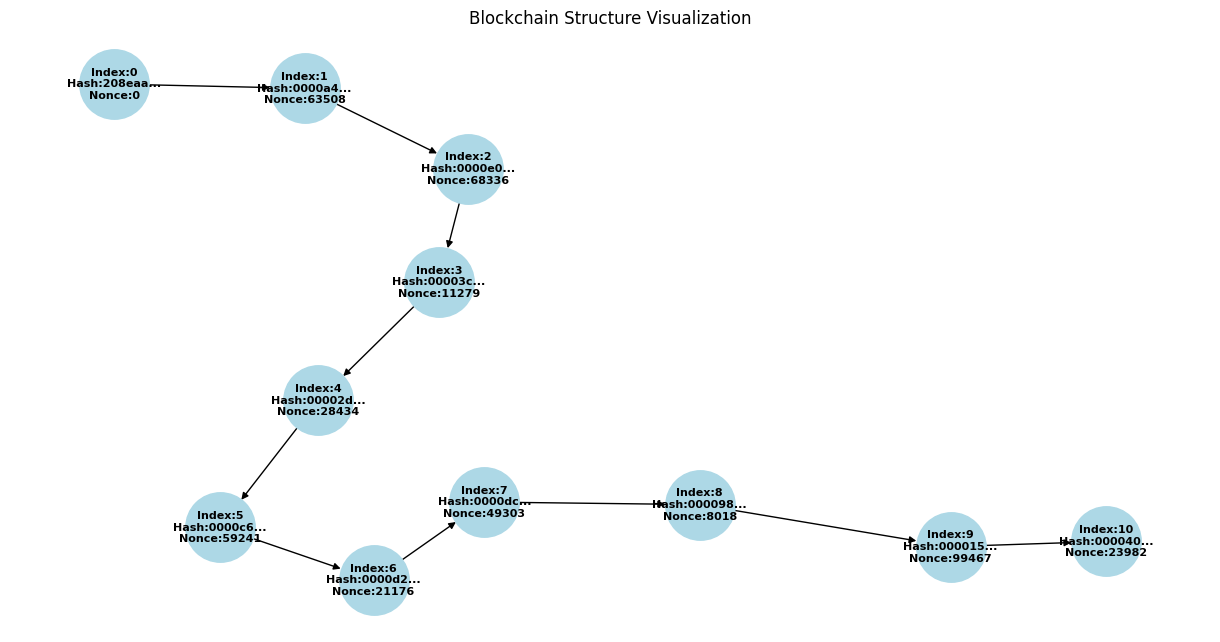

In [1]:
import hashlib
import datetime
import networkx as nx
import matplotlib.pyplot as plt

class Block:
    def __init__(self, index, timestamp, data, previous_hash):
        self.index = index
        self.timestamp = timestamp
        self.data = data
        self.previous_hash = previous_hash
        self.nonce = 0
        self.hash = self.calculate_hash()

    def calculate_hash(self):
        content = str(self.index) + str(self.timestamp) + str(self.data) + str(self.previous_hash) + str(self.nonce)
        return hashlib.sha256(content.encode()).hexdigest()

    def mine_block(self, difficulty):
        prefix = '0' * difficulty
        while self.hash[:difficulty] != prefix:
            self.nonce += 1
            self.hash = self.calculate_hash()

class Blockchain:
    def __init__(self):
        self.chain = [self.create_genesis_block()]
        self.difficulty = 4

    def create_genesis_block(self):
        return Block(0, datetime.datetime.now(), "Genesis Block", "0")

    def get_latest_block(self):
        return self.chain[-1]

    def add_block(self, new_block):
        new_block.previous_hash = self.get_latest_block().hash
        new_block.mine_block(self.difficulty)
        self.chain.append(new_block)

    def is_chain_valid(self):
        for i in range(1, len(self.chain)):
            curr = self.chain[i]
            prev = self.chain[i-1]

            if curr.hash != curr.calculate_hash():
                return False
            if curr.previous_hash != prev.hash:
                return False
        return True

def plot_blockchain(blockchain):
    G = nx.DiGraph()

    for block in blockchain.chain:
        label = f"Index:{block.index}\nHash:{block.hash[:6]}...\nNonce:{block.nonce}"
        G.add_node(block.index, label=label)

    for i in range(1, len(blockchain.chain)):
        G.add_edge(blockchain.chain[i-1].index, blockchain.chain[i].index)

    pos = nx.spring_layout(G, seed=42)  # layout for neat visualization
    labels = nx.get_node_attributes(G, 'label')
    plt.figure(figsize=(12,6))
    nx.draw(G, pos, with_labels=True, labels=labels, node_size=2500, node_color='lightblue', font_size=8, font_weight='bold', arrows=True)
    plt.title("Blockchain Structure Visualization")
    plt.show()

# Main execution

my_blockchain = Blockchain()

for i in range(1, 11):
    print(f"Mining block {i}...")
    data = {"amount": i * 10}
    new_block = Block(i, datetime.datetime.now(), data, "")
    my_blockchain.add_block(new_block)

# Print blockchain details
for block in my_blockchain.chain:
    print(f"Index: {block.index}")
    print(f"Timestamp: {block.timestamp}")
    print(f"Data: {block.data}")
    print(f"Hash: {block.hash}")
    print(f"Previous Hash: {block.previous_hash}\n")

print("Is blockchain valid?", my_blockchain.is_chain_valid())

# Plot the blockchain structure
plot_blockchain(my_blockchain)
